# Explore Garmin data, prepocess it & export to csv

## Sources:
- [Analysis of Running Activities from Garmin Watch Using Python](https://towardsdatascience.com/analysis-of-runing-activities-from-garmin-watch-using-python-99609f83314e)
- [Week number of the month?](https://stackoverflow.com/questions/3806473/week-number-of-the-month)

## ToDo:
- decide what to do when multiple activies in same day

## Import modules

In [1]:
# import internal modules
# from typing import List, Set, Dict, TypedDict, Tuple, Optional, Union
from pathlib import Path

# import 3rd-party modules
import pandas as pd
import numpy as np
import calendar

# import local modules

## Define functions

In [2]:
# Create Function to explore the dataframes
def explore(df: pd.DataFrame) -> None:
    """
    Function to print general information about the dataframe
    """
    print("********** 1. General info of data **********")
    print(df.info())
    
    print("\n********** 2. Shape of data **********")
    print(f"Number of rows: {len(df)}")
    print(f"Number of columns: {len(df.columns)}")
    
    print("\n********** 3. Number of missing values per column **********")
    print(df.isnull().sum())
    
    print("\n********** 4. Number of duplicated values **********")
    print(df.duplicated().sum())
    
    print("\n********** 5. Number of unique values per column (NaN non included) **********")
    print(df.nunique())
    
    print("\n********** 6. Statistical info of each column **********")
    # print(df.describe(include='all').T)
    return df.describe(include='all', datetime_is_numeric=True).T

def convert_strings_to_duration(str_series):
    """
    Function to convert series of strings to durations; workaround when multiple formats in series
    """
    return pd.to_timedelta(pd.to_datetime(str_series).dt.strftime("%H:%M:%S.%f"))

def convert_durations_to_minutes(durations_series):
    # durations_series.dt.hour*60 + durations_series.dt.minute + durations_series.dt.second/60
    return durations_series.dt.total_seconds()/60

def get_calendar_week_of_month(year, month, day):
    calendar_month = np.array(calendar.monthcalendar(year, month))
    week_of_month = np.where(calendar_month==day)[0][0]

    return week_of_month

def normalize_between_range(xs, a, b):
    """
    Function to normalize a series between range [a,b]
    """
    min_x = np.min(xs)
    max_x = np.max(xs)
    return (b - a) * (xs - min_x)/(max_x - min_x) + a

## Read data

In [3]:
# set csv path
df_path = Path("assets/data/garmin_data/Activities_20210304_20221027.csv")

# read csv into dataframe
df = pd.read_csv(df_path, parse_dates=True)

## Explore data (Exploratory data analysis)

In [4]:
df.head()

,Activity Type,Date,Favorite,Title,Distance,Calories,Time,Avg HR,Max HR,Aerobic TE,...,Min Resp,Max Resp,Stress Change,Stress Start,Stress End,Avg Stress,Moving Time,Elapsed Time,Min Elevation,Max Elevation
0,Breathwork,2022-10-27 23:57:54,False,Coherence,0.00,--,00:15:34,67,92,0.0,...,4,10,-53,80,27,36,00:00:00,00:15:34,--,--
1,Cycling,2022-10-27 18:08:56,False,Sint-Lambrechts-Woluwe Cycling,8.87,199,00:30:42,112,130,1.4,...,--,--,--,--,--,--,00:29:42,00:37:10,48,108
2,Cycling,2022-10-27 11:24:30,False,Ukkel Cycling,9.72,210,00:34:13,110,139,1.6,...,--,--,--,--,--,--,00:33:10,00:43:03,51,115
3,Breathwork,2022-10-27 01:27:24,False,Coherence,0.00,--,00:15:34,75,107,0.0,...,3,13,-44,93,49,54,00:00:00,00:15:34,--,--
4,Strength Training,2022-10-26 19:18:30,False,Strength,0.00,543,01:55:09,106,150,1.8,...,--,--,--,--,--,--,00:33:25,01:55:09,--,--


In [5]:
explore(df)

********** 1. General info of data **********
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 50 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Activity Type             889 non-null    object 
 1   Date                      889 non-null    object 
 2   Favorite                  889 non-null    bool   
 3   Title                     889 non-null    object 
 4   Distance                  889 non-null    object 
 5   Calories                  889 non-null    object 
 6   Time                      889 non-null    object 
 7   Avg HR                    889 non-null    int64  
 8   Max HR                    889 non-null    int64  
 9   Aerobic TE                889 non-null    object 
 10  Avg Run Cadence           889 non-null    object 
 11  Max Run Cadence           889 non-null    object 
 12  Avg Speed                 889 non-null    object 
 13  Max Speed          

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Activity Type,889,9,Cycling,434,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,889,889,2021-12-28 19:30:07,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Favorite,889,1,False,889,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Title,889,39,Vilvoorde Cycling,220,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Distance,889,468,0.00,301,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Calories,889,404,--,201,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Time,889,654,00:15:34,187,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Avg HR,889.0,NaN,NaN,NaN,104.457818,26.980028,44.0,97.0,112.0,121.0,165.0
Max HR,889.0,NaN,NaN,NaN,135.268841,31.304965,58.0,123.0,143.0,155.0,199.0
Aerobic TE,889,48,0.0,197,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df["Activity Type"].unique()

array(['Breathwork', 'Cycling', 'Strength Training', 'Other',
       'Pool Swimming', 'Cardio', 'Running', 'Yoga', 'Pilates'],
      dtype=object)

In [7]:
df.loc[df["Activity Type"] == "Other"].Title.unique()

array(['Kraainem Tennis', 'Tennis', 'Grimbergen Football',
       'Vilvoorde Tennis', 'Brussels Tennis', 'Jette Football',
       'Evere Tennis', 'Schaarbeek Football', 'Ukkel Football',
       'Ottignies-Louvain-la-Neuve Tennis', 'Football',
       'Brussels Bouldering'], dtype=object)

## Clean data

In [8]:
# map "other" activity type according to title
df.loc[df["Title"].str.contains("Football"), "Activity Type"] = "Football"
df.loc[df["Title"].str.contains("Tennis"), "Activity Type"] = "Tennis"
df.loc[df["Title"].str.contains("Bouldering"), "Activity Type"] = "Strength Training"

In [9]:
df["Activity Type"].unique()

array(['Breathwork', 'Cycling', 'Strength Training', 'Tennis', 'Football',
       'Pool Swimming', 'Cardio', 'Running', 'Yoga', 'Pilates'],
      dtype=object)

In [10]:
# select columns to keep
selected_cols = [
    "Activity Type",
    "Date",
    "Distance",
    "Calories",	"Time", "Avg HR", "Max HR", "Aerobic TE", "Avg Run Cadence",
    "Max Run Cadence", "Avg Speed", "Max Speed", "Total Ascent", "Total Descent", "Avg Stride Length", 
    # "Best Lap Time", 
    "Number of Laps", "Max Temp", 
    # "Moving Time", "Elapsed Time", 
    "Min Elevation", "Max Elevation"
    ]

df = df[selected_cols]

### ToDo: find better solution to parse duration strings
ideas: 
- coerce error to convert error to nan and then fill na with other format
- consolidate strings in 1 format

In [11]:
# convert concerned cols to date & duration time
# df['Date'] = pd.to_datetime(pd.to_datetime(df['Date']).dt.date)
df['Date'] = pd.to_datetime(df.loc[:, 'Date'])
print("Date converted")
df["Date_yy-mm-dd"] = pd.to_datetime(df.loc[:, 'Date']).dt.date
print("Date_yy-mm-dd converted")
df['Time'] = convert_strings_to_duration(df.loc[:, 'Time'])
print("Time converted")
# df['Elapsed Time'] = convert_strings_to_duration(df.loc[:, 'Elapsed Time'])
# print("Elapsed Time converted")
# df['Best Lap Time'] = df.loc[:, 'Best Lap Time'].apply(lambda x: f"00:{x}" if x.count(":") == 1 else x) # need to add hh:
# df['Best Lap Time'] = pd.to_timedelta(df.loc[:, 'Best Lap Time'])
# print("Best Lap Time converted")
# df['Moving Time'] = convert_strings_to_duration(df.loc[:, 'Moving Time'])
# print("Moving Time converted")

# convert durations cols to number of minutes
duration_cols = df.select_dtypes(include=["timedelta64[ns]"]).columns

for duration_col in duration_cols:
    df[duration_col] = convert_durations_to_minutes(df[duration_col])

Date converted
Date_yy-mm-dd converted
Time converted


In [12]:
# replace dummy value "--" by 0 (toDo: check impact of this replacement for other activities)
df.loc[:, "Calories"].replace({'--':'0'}, inplace=True)

# replace dummy value "--" by nan
df.replace({'--':np.nan}, inplace=True)

# # remove comma (to indicate thousands)
# df["Calories"] = df.loc[:, "Calories"].str.replace(',', "")
# df["Distance"] = df.loc[:, "Distance"].str.replace(',', "")

In [13]:
# convert object cols to float
## select only object cols
object_cols = df.select_dtypes(include='object').columns.to_list()

## remove title from object cols
object_cols.remove("Activity Type")
object_cols.remove("Avg Speed") # toDo: convert swimming pace (e.g. 1:58 /100m to kph)
object_cols.remove("Max Speed") # toDo: convert swimming pace (e.g. 1:58 /100m to kph)
object_cols.remove("Date_yy-mm-dd")

## remove comma (to indicate thousands)
for object_col in object_cols:
    df[object_col] = df[object_col].str.replace(',', "")

## convert object cols to float
df[object_cols] = df[object_cols].astype("float")

## inspect cols info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Activity Type      889 non-null    object        
 1   Date               889 non-null    datetime64[ns]
 2   Distance           889 non-null    float64       
 3   Calories           889 non-null    float64       
 4   Time               889 non-null    float64       
 5   Avg HR             889 non-null    int64         
 6   Max HR             889 non-null    int64         
 7   Aerobic TE         888 non-null    float64       
 8   Avg Run Cadence    888 non-null    float64       
 9   Max Run Cadence    888 non-null    float64       
 10  Avg Speed          589 non-null    object        
 11  Max Speed          589 non-null    object        
 12  Total Ascent       552 non-null    float64       
 13  Total Descent      553 non-null    float64       
 14  Avg Stride

In [14]:
df.head()

,Activity Type,Date,Distance,Calories,Time,Avg HR,Max HR,Aerobic TE,Avg Run Cadence,Max Run Cadence,Avg Speed,Max Speed,Total Ascent,Total Descent,Avg Stride Length,Number of Laps,Max Temp,Min Elevation,Max Elevation,Date_yy-mm-dd
0,Breathwork,2022-10-27 23:57:54,0.00,0.0,15.566667,67,92,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.0,177,0.0,NaN,NaN,2022-10-27
1,Cycling,2022-10-27 18:08:56,8.87,199.0,30.700000,112,130,1.4,0.0,0.0,17.3,35.7,33.0,76.0,0.0,2,0.0,48.0,108.0,2022-10-27
2,Cycling,2022-10-27 11:24:30,9.72,210.0,34.216667,110,139,1.6,0.0,0.0,17.0,30.7,77.0,68.0,0.0,2,0.0,51.0,115.0,2022-10-27
3,Breathwork,2022-10-27 01:27:24,0.00,0.0,15.566667,75,107,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.0,177,0.0,NaN,NaN,2022-10-27
4,Strength Training,2022-10-26 19:18:30,0.00,543.0,115.150000,106,150,1.8,0.0,0.0,NaN,NaN,NaN,NaN,0.0,1,0.0,NaN,NaN,2022-10-26


In [15]:
df[["Date"]].nunique()

Date    889
dtype: int64

## Group activities by date

In [16]:
# select columns
selected_cols = ["Date_yy-mm-dd", "Activity Type", "Distance", "Calories", "Time", "Avg HR", "Max HR"]

# group dataframe by date and activity Type
grouped_df_group = df[selected_cols].groupby(["Date_yy-mm-dd", "Activity Type"])
# grouped_by_date_df_group.groups

# aggregate values
grouped_df = grouped_df_group.agg({
    'Distance' : 'sum', 
    'Calories' : 'sum', 
    'Time' : 'sum', 
    'Avg HR' : 'mean',
    'Max HR' : 'mean'
    })

# reset index to have Date_yy-mm-dd col as regular column
grouped_df.reset_index(inplace=True)

# now, we can convert Date_yy-mm-dd column to datetime
grouped_df["Date_yy-mm-dd"] = pd.to_datetime(grouped_df["Date_yy-mm-dd"])
grouped_df.head()

,Date_yy-mm-dd,Activity Type,Distance,Calories,Time,Avg HR,Max HR
0,2021-03-04,Strength Training,0.0,411.0,62.933333,119.0,153.0
1,2021-03-05,Breathwork,0.0,0.0,5.841667,59.0,73.0
2,2021-03-05,Pilates,0.0,7.0,5.665000,75.0,92.0
3,2021-03-05,Yoga,0.0,1.0,2.826667,75.0,86.0
4,2021-03-07,Breathwork,0.0,0.0,15.566667,63.0,84.0


In [17]:
# get date range of dataframe
# date_start = df[["Date"]].min().dt.date.values[0]
# date_end = df[["Date"]].max().dt.date.values[0]
# print(date_start)
# print(date_end)

# get starting year and ending year
date_start = df[["Date"]].min().dt.year.values[0]
date_end = df[["Date"]].max().dt.year.values[0]
date_start = str(date_start) + "-01-01"
date_end = str(date_end) + "-12-31"
print("start date", date_start)
print("end date", date_end)

# get days between range date and make a dataframe from these days
range_date = pd.date_range(start=date_start, end=date_end, freq ='D')
range_date_df = pd.DataFrame(range_date, columns = ['Date_yy-mm-dd'])

# add date related columns to dataframe
range_date_df["Year"] = pd.to_datetime(range_date_df["Date_yy-mm-dd"]).dt.year
range_date_df["Month"] = pd.to_datetime(range_date_df["Date_yy-mm-dd"]).dt.month
range_date_df["Month_name"] = pd.to_datetime(range_date_df["Date_yy-mm-dd"]).dt.month_name()
range_date_df["Day"] = pd.to_datetime(range_date_df["Date_yy-mm-dd"]).dt.day
range_date_df["Day_name"] = pd.to_datetime(range_date_df["Date_yy-mm-dd"]).dt.day_name()
range_date_df["Day_of_week"] = pd.to_datetime(range_date_df["Date_yy-mm-dd"]).dt.day_of_week
# range_date_df["Week_of_month"] = pd.to_datetime(range_date_df["Date_yy-mm-dd"]).apply(lambda x: (x.day - 1)//7 + 1)
range_date_df["Week_of_month"] = range_date_df.apply(lambda x: get_calendar_week_of_month(x.Year, x.Month, x.Day), axis=1)

# add column: number of days in month
range_date_df["Days_in_month"] = pd.to_datetime(range_date_df["Date_yy-mm-dd"]).dt.days_in_month
range_date_df

start date 2021-01-01
end date 2022-12-31


,Date_yy-mm-dd,Year,Month,Month_name,Day,Day_name,Day_of_week,Week_of_month,Days_in_month
0,2021-01-01,2021,1,January,1,Friday,4,0,31
1,2021-01-02,2021,1,January,2,Saturday,5,0,31
2,2021-01-03,2021,1,January,3,Sunday,6,0,31
3,2021-01-04,2021,1,January,4,Monday,0,1,31
4,2021-01-05,2021,1,January,5,Tuesday,1,1,31
...,...,...,...,...,...,...,...,...,...
725,2022-12-27,2022,12,December,27,Tuesday,1,4,31
726,2022-12-28,2022,12,December,28,Wednesday,2,4,31
727,2022-12-29,2022,12,December,29,Thursday,3,4,31
728,2022-12-30,2022,12,December,30,Friday,4,4,31


In [18]:
# merge dataframe with all days from date range and dataframe with aggregated activities values
everyday_grouped_df = pd.merge(range_date_df, grouped_df, how="left", on="Date_yy-mm-dd")
everyday_grouped_df.head()

,Date_yy-mm-dd,Year,Month,Month_name,Day,Day_name,Day_of_week,Week_of_month,Days_in_month,Activity Type,Distance,Calories,Time,Avg HR,Max HR
0,2021-01-01,2021,1,January,1,Friday,4,0,31,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-02,2021,1,January,2,Saturday,5,0,31,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-01-03,2021,1,January,3,Sunday,6,0,31,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-01-04,2021,1,January,4,Monday,0,1,31,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-01-05,2021,1,January,5,Tuesday,1,1,31,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
# # get number of days per month and year
# nb_days_per_month_df = everyday_grouped_df[["Year", "Month", "Day"]].groupby(["Year", "Month"]).nunique()

# get number of activities per day
nb_activities_per_day = everyday_grouped_df[["Date_yy-mm-dd"]].value_counts(sort=False)
nb_activities_per_day = nb_activities_per_day.reset_index().rename(columns={0:"Total_nb_activities_per_day"})

# everyday_grouped_df[["Year", "Month", "Day"]].groupby(["Year", "Month"]).agg(["nunique", "count"])

# add number of activities per day to dataframe
everyday_grouped_df = pd.merge(everyday_grouped_df, nb_activities_per_day, how="left", on="Date_yy-mm-dd")
everyday_grouped_df.head()

,Date_yy-mm-dd,Year,Month,Month_name,Day,Day_name,Day_of_week,Week_of_month,Days_in_month,Activity Type,Distance,Calories,Time,Avg HR,Max HR,Total_nb_activities_per_day
0,2021-01-01,2021,1,January,1,Friday,4,0,31,NaN,NaN,NaN,NaN,NaN,NaN,1
1,2021-01-02,2021,1,January,2,Saturday,5,0,31,NaN,NaN,NaN,NaN,NaN,NaN,1
2,2021-01-03,2021,1,January,3,Sunday,6,0,31,NaN,NaN,NaN,NaN,NaN,NaN,1
3,2021-01-04,2021,1,January,4,Monday,0,1,31,NaN,NaN,NaN,NaN,NaN,NaN,1
4,2021-01-05,2021,1,January,5,Tuesday,1,1,31,NaN,NaN,NaN,NaN,NaN,NaN,1


In [20]:
def get_calendar_grid_coords_xyz(
    day_of_week, week_of_month, month, year, year_min, day_cell_shape=(1,1), day_grid_offset=(2,2),
    month_grid_offset=(1.2,1.2),
    year_grid_offset=1.5,
    nb_months_per_row=4):

    month -= 1
    
    nb_days_in_week = 7
    nb_months = 12
    nb_months_per_col = nb_months // nb_months_per_row
    year_nb = year - year_min

    day_cell_x, day_cell_y = day_of_week, week_of_month
    month_cell_x, month_cell_y = month//nb_months_per_row, month - nb_months_per_row*(month//nb_months_per_row)
    year_cell_x, year_cell_y = 0, year_nb

    day_cell_width, day_cell_height = day_cell_shape
    day_grid_offset_x, day_grid_offset_y = day_grid_offset
    month_grid_offset_x, month_grid_offset_y = month_grid_offset

    month_grid_width = day_cell_width * nb_days_in_week * day_grid_offset_x
    month_grid_height = day_cell_height * nb_days_in_week * day_grid_offset_y
    # year_grid_width = month_grid_width * nb_months_per_row * month_grid_offset_x
    year_grid_height = month_grid_height * nb_months_per_col * month_grid_offset_y

    x = day_cell_x * day_cell_width * day_grid_offset_x + month_cell_x * month_grid_width * month_grid_offset_x
    y = day_cell_y * day_cell_height * day_grid_offset_y + month_cell_y * month_grid_height * month_grid_offset_y + year_cell_y * year_grid_height * year_grid_offset

    return x,y

year_min = everyday_grouped_df.Year.min()

everyday_grouped_df["grid_coords_xy"] = everyday_grouped_df.apply(lambda x: get_calendar_grid_coords_xyz(x.Day_of_week, x.Week_of_month, x.Month, x.Year, year_min), axis=1)
everyday_grouped_df.head(15)

,Date_yy-mm-dd,Year,Month,Month_name,Day,Day_name,Day_of_week,Week_of_month,Days_in_month,Activity Type,Distance,Calories,Time,Avg HR,Max HR,Total_nb_activities_per_day,grid_coords_xy
0,2021-01-01,2021,1,January,1,Friday,4,0,31,NaN,NaN,NaN,NaN,NaN,NaN,1,"(8.0, 0.0)"
1,2021-01-02,2021,1,January,2,Saturday,5,0,31,NaN,NaN,NaN,NaN,NaN,NaN,1,"(10.0, 0.0)"
2,2021-01-03,2021,1,January,3,Sunday,6,0,31,NaN,NaN,NaN,NaN,NaN,NaN,1,"(12.0, 0.0)"
3,2021-01-04,2021,1,January,4,Monday,0,1,31,NaN,NaN,NaN,NaN,NaN,NaN,1,"(0.0, 2.0)"
4,2021-01-05,2021,1,January,5,Tuesday,1,1,31,NaN,NaN,NaN,NaN,NaN,NaN,1,"(2.0, 2.0)"
5,2021-01-06,2021,1,January,6,Wednesday,2,1,31,NaN,NaN,NaN,NaN,NaN,NaN,1,"(4.0, 2.0)"
6,2021-01-07,2021,1,January,7,Thursday,3,1,31,NaN,NaN,NaN,NaN,NaN,NaN,1,"(6.0, 2.0)"
7,2021-01-08,2021,1,January,8,Friday,4,1,31,NaN,NaN,NaN,NaN,NaN,NaN,1,"(8.0, 2.0)"
8,2021-01-09,2021,1,January,9,Saturday,5,1,31,NaN,NaN,NaN,NaN,NaN,NaN,1,"(10.0, 2.0)"
9,2021-01-10,2021,1,January,10,Sunday,6,1,31,NaN,NaN,NaN,NaN,NaN,NaN,1,"(12.0, 2.0)"


In [21]:
# year_min = everyday_grouped_df.Year.min()
# nb_months = 12
# nb_cols_per_year = 4
# nb_rows_per_year = nb_months // nb_cols_per_year
# nb_days_in_month_max = 31
# nb_days_in_week = 7


# year_grid_width = 1 * nb_cols_per_year * nb_days_in_week
# year_grid_height = 1 * nb_rows_per_year * 5
# def get_grid_coords_xyz(row, year_min, year_grid_height):
#     year_nb = row["Year"] - year_min
#     year_grid_x = 0
#     year_grid_y = year_grid_height * year_nb
#     month = row["Month"] - 1
#     month_grid_x, month_grid_y = month//nb_rows_per_year, month - nb_cols_per_year*(month//nb_cols_per_year)
#     month_grid_width = nb_days_in_week
#     month_grid_height = row['Days_in_month']// nb_days_in_week
#     day_grid_x, day_grid_y = row['Day_of_week'], row['Week_of_month']
#     day_grid_y = (2*row['Day'] - day_grid_x - 1)//7 + 1

#     x = year_grid_x + month_grid_x * month_grid_width  + (day_grid_x)
#     y = year_grid_y + month_grid_y * month_grid_height + (day_grid_y)

#     return x,y

# everyday_grouped_df["grid_coords_xy"] = everyday_grouped_df.apply(get_grid_coords_xyz, args=(year_min, year_grid_height), axis=1)
# everyday_grouped_df.head(15)

## Export dataframes as csv

In [22]:
# set output csv path
out_csv_path = df_path.parent / f"{df_path.stem}_cleaned.csv"
df.to_csv(out_csv_path, index=False)

In [23]:
# set output csv path
out_csv_path = df_path.parent / f"{df_path.stem}_cleaned_grouped.csv"
grouped_df.to_csv(out_csv_path, index=False)

In [24]:
# set output csv path
out_csv_path = df_path.parent / f"{df_path.stem}_cleaned_grouped_all_days.csv"
everyday_grouped_df.to_csv(out_csv_path, index=False)

In [25]:
everyday_grouped_df.iloc[500:550]

,Date_yy-mm-dd,Year,Month,Month_name,Day,Day_name,Day_of_week,Week_of_month,Days_in_month,Activity Type,Distance,Calories,Time,Avg HR,Max HR,Total_nb_activities_per_day,grid_coords_xy
500,2022-01-18,2022,1,January,18,Tuesday,1,3,31,Breathwork,0.00,0.0,15.566667,48.000000,81.000000,2,"(2.0, 81.6)"
501,2022-01-18,2022,1,January,18,Tuesday,1,3,31,Cycling,16.68,396.0,60.350000,119.000000,143.000000,2,"(2.0, 81.6)"
502,2022-01-19,2022,1,January,19,Wednesday,2,3,31,Cycling,17.31,531.0,75.366667,125.000000,171.000000,1,"(4.0, 81.6)"
503,2022-01-20,2022,1,January,20,Thursday,3,3,31,Breathwork,0.00,0.0,15.566667,52.000000,79.000000,2,"(6.0, 81.6)"
504,2022-01-20,2022,1,January,20,Thursday,3,3,31,Strength Training,0.00,144.0,37.750000,92.000000,125.000000,2,"(6.0, 81.6)"
505,2022-01-21,2022,1,January,21,Friday,4,3,31,Breathwork,0.00,0.0,15.566667,65.000000,82.000000,2,"(8.0, 81.6)"
506,2022-01-21,2022,1,January,21,Friday,4,3,31,Cycling,18.97,702.0,100.966667,122.500000,166.000000,2,"(8.0, 81.6)"
507,2022-01-22,2022,1,January,22,Saturday,5,3,31,Cycling,24.08,757.0,112.683333,125.000000,171.000000,1,"(10.0, 81.6)"
508,2022-01-23,2022,1,January,23,Sunday,6,3,31,Breathwork,0.00,0.0,46.700000,66.666667,88.333333,2,"(12.0, 81.6)"
509,2022-01-23,2022,1,January,23,Sunday,6,3,31,Cycling,20.06,614.0,70.466667,129.000000,162.000000,2,"(12.0, 81.6)"


In [26]:
everyday_grouped_df[(everyday_grouped_df["Year"] == 2021) & (everyday_grouped_df["Month"] == 7)]

,Date_yy-mm-dd,Year,Month,Month_name,Day,Day_name,Day_of_week,Week_of_month,Days_in_month,Activity Type,Distance,Calories,Time,Avg HR,Max HR,Total_nb_activities_per_day,grid_coords_xy
230,2021-07-01,2021,7,July,1,Thursday,3,0,31,Breathwork,0.00,0.0,15.566667,54.0,76.0,3,"(22.8, 33.6)"
231,2021-07-01,2021,7,July,1,Thursday,3,0,31,Cycling,24.56,601.0,88.100000,117.0,144.5,3,"(22.8, 33.6)"
232,2021-07-01,2021,7,July,1,Thursday,3,0,31,Tennis,2.63,484.0,94.150000,111.0,131.0,3,"(22.8, 33.6)"
233,2021-07-02,2021,7,July,2,Friday,4,0,31,Cycling,24.62,535.0,82.666667,113.0,141.0,2,"(24.8, 33.6)"
234,2021-07-02,2021,7,July,2,Friday,4,0,31,Tennis,3.66,608.0,121.333333,111.0,140.0,2,"(24.8, 33.6)"
235,2021-07-03,2021,7,July,3,Saturday,5,0,31,Breathwork,0.00,0.0,1.105000,70.0,96.0,3,"(26.8, 33.6)"
236,2021-07-03,2021,7,July,3,Saturday,5,0,31,Cycling,5.01,161.0,20.933333,119.0,152.0,3,"(26.8, 33.6)"
237,2021-07-03,2021,7,July,3,Saturday,5,0,31,Tennis,1.97,316.0,52.050000,113.0,141.0,3,"(26.8, 33.6)"
238,2021-07-04,2021,7,July,4,Sunday,6,0,31,Cycling,4.33,125.0,17.825000,110.0,129.0,2,"(28.8, 33.6)"
239,2021-07-04,2021,7,July,4,Sunday,6,0,31,Football,6.58,719.0,72.271667,137.5,159.5,2,"(28.8, 33.6)"


In [27]:
# # get list of years (without duplicates) and sort it
# years = everyday_grouped_df["Year"].unique()
# years.sort()

# months = everyday_grouped_df[["Month", "Month_name"]].drop_duplicates()
# months.sort_values(by="Month")

In [ ]:
import bpy
import pandas as pd
import numpy as np

# read csv file into pandas dataframe
df = pd.read_csv("/Users/derrickvanfrausum/BeCode_AI/git-repos/coding-art/core/assets/data/garmin_data/Activities_20210304_20220818_cleaned_grouped_all_days.csv")

# get list of dates (without duplicates) and sort it
dates = df["Date_yy-mm-dd"].unique()
dates.sort()

# iterate over activity date
for i, activity_date in enumerate(dates):

    # get activities for current date
    activities_times = df.loc[df["Date_yy-mm-dd"] == activity_date, "Time"]
    
    # get day name
    day_name = df.loc[df["Date_yy-mm-dd"] == activity_date, "Day_name"].values[0]
    
    if day_name == "Monday":
        x = 0
    
    elif day_name == "Tuesday":
        x = 2
        
    elif day_name == "Wednesday":
        x = 4
        
    elif day_name == "Thursday":
        x = 6
        
    elif day_name == "Friday":
        x = 8
        
    elif day_name == "Saturday":
        x = 10
        
    elif day_name == "Sunday":
        x = 12
        
    
    # iterate over y values
    for y, time in enumerate(activities_times):
        
        if time == np.nan:
            time = 0.0

        if y%2 == 0:
            x_grid = x
        else:
            x_grid = x + 1
            
        location = (x_grid, y + i*2, time/2)
        
        # add cube
        bpy.ops.mesh.primitive_cube_add(size=1, enter_editmode=False, align='WORLD', location=location, scale=(1, 1, time))

In [ ]:
import bpy
import pandas as pd
import numpy as np

# read csv file into pandas dataframe
df = pd.read_csv("/Users/derrickvanfrausum/BeCode_AI/git-repos/coding-art/core/assets/data/garmin_data/Activities_20210304_20220818_cleaned_grouped_all_days.csv")

# get list of dates (without duplicates) and sort it
dates = df["Date_yy-mm-dd"].unique()
dates.sort()

x = 0
y = 0
# iterate over activity date
for i, activity_date in enumerate(dates):

    # get activities for current date
    activities_times = df.loc[df["Date_yy-mm-dd"] == activity_date, "Time"]
    
    if i%15 == 0:
        x = 0
        y += 3
        
    else:
        x += 2
    
    # iterate over y values
    for j, time in enumerate(activities_times):
        
        if time == np.nan:
            time = 0.0

        if j%2 == 0:
            x_grid = x
            j += 2
        else:
            x_grid = x + 1
            
        location = (x_grid, y+j, time/2)
        
        # add cube
        bpy.ops.mesh.primitive_cube_add(size=1, enter_editmode=False, align='WORLD', location=location, scale=(1, 1, time))

In [ ]:
import bpy
import pandas as pd
import numpy as np
import sys

utility_directory = "/Users/derrickvanfrausum/BeCode_AI/git-repos/coding-art/core/models_3d"
sys.path.append(utility_directory)


import blender_utils

def normalize_between_range(xs, a, b):
    """
    Function to normalize a series between range [a,b]
    """
    min_x = np.min(xs)
    max_x = np.max(xs)
    return (b - a) * (xs - min_x)/(max_x - min_x) + a


# read csv file into pandas dataframe
df = pd.read_csv("/Users/derrickvanfrausum/BeCode_AI/git-repos/coding-art/core/assets/data/garmin_data/Activities_20210304_20220818_cleaned_grouped_all_days.csv")

# get list of dates (without duplicates) and sort it
dates = df["Date_yy-mm-dd"].unique()
dates.sort()

df["Time"] = normalize_between_range(df["Time"], 0,20)

# iterate over activity date
for i, activity_date in enumerate(dates):

    # get activities for current date
    activities_times = df.loc[df["Date_yy-mm-dd"] == activity_date, "Time"]
    xys = df.loc[df["Date_yy-mm-dd"] == activity_date, "grid_coords_xy"]
    
    total_time = 0.0
    
    # iterate over y values
    for j, time in enumerate(activities_times):
        
        if time == np.nan:
            time = 0.0
            
        total_time += time
        
    x, y = xys.iloc[j][1:-1].split(",")
    
    location = (float(x),float(y), time/2)
    
    # add cube
    bpy.ops.mesh.primitive_cube_add(size=1, enter_editmode=False, align='WORLD', location=location, scale=(1, 1, time))
    
    # add y label text and set transform properties (add initial y text that will be updated at each frame)
    y_text_obj = blender_utils.add_text(activity_date)
    # y_text_obj.rotation_euler[0] = 1.5708 # 90°
    y_text_obj.scale = (0.2, 0.2, 0.2)
    y_text_obj.location = location[0], location[1], - 4

In [478]:
nb_frames = 100
fps = 30
heartrate_per_sec = 180 / 60
heartrate_step_for_animation = int(fps/heartrate_per_sec)
# heartrate_step_for_animation = round((heartrate_per_sec/fps) * nb_frames)
heatrate_values = np.zeros(shape=(nb_frames//heartrate_step_for_animation, heartrate_step_for_animation))
# heatrate_values[::heartrate_step_for_animation] = 1
heartrate_half_step = heartrate_step_for_animation//2 + 1
modulo_hr_half_step = heartrate_step_for_animation%2
first_half_step_values = np.logspace(0, -2, num=heartrate_half_step)
second_half_step_values = np.logspace(-2, 0, num=heartrate_half_step)
# second_half_step_values = np.logspace(0, -1, base=np.exp(2), num=heartrate_half_step)

smooth_heartrate_step = np.append(first_half_step_values[:heartrate_half_step - 1 + modulo_hr_half_step], second_half_step_values[:-1])
# smooth_heartrate_step = np.append(first_half_step_values[1:], second_half_step_values[1:])
# heatrate_values = heatrate_values.reshape((len(heatrate_values)//heartrate_step_for_animation, heartrate_step_for_animation))
heatrate_values[:] = smooth_heartrate_step
heatrate_values = heatrate_values.reshape(-1)
modulo_hr = nb_frames%heartrate_step_for_animation
remaining_heartrate_values = np.zeros(modulo_hr)
remaining_heartrate_values = first_half_step_values[:modulo_hr]
heatrate_values = np.append(heatrate_values, remaining_heartrate_values)
heatrate_values

array([1.        , 0.39810717, 0.15848932, 0.06309573, 0.02511886,
       0.01      , 0.02511886, 0.06309573, 0.15848932, 0.39810717,
       1.        , 0.39810717, 0.15848932, 0.06309573, 0.02511886,
       0.01      , 0.02511886, 0.06309573, 0.15848932, 0.39810717,
       1.        , 0.39810717, 0.15848932, 0.06309573, 0.02511886,
       0.01      , 0.02511886, 0.06309573, 0.15848932, 0.39810717,
       1.        , 0.39810717, 0.15848932, 0.06309573, 0.02511886,
       0.01      , 0.02511886, 0.06309573, 0.15848932, 0.39810717,
       1.        , 0.39810717, 0.15848932, 0.06309573, 0.02511886,
       0.01      , 0.02511886, 0.06309573, 0.15848932, 0.39810717,
       1.        , 0.39810717, 0.15848932, 0.06309573, 0.02511886,
       0.01      , 0.02511886, 0.06309573, 0.15848932, 0.39810717,
       1.        , 0.39810717, 0.15848932, 0.06309573, 0.02511886,
       0.01      , 0.02511886, 0.06309573, 0.15848932, 0.39810717,
       1.        , 0.39810717, 0.15848932, 0.06309573, 0.02511

In [ ]:
heartrate_step_for_animation

In [ ]:
a = np.zeros(100)
heartrate_per_sec = 180 / 60
heartrate_per_frame = heartrate_per_sec / fps
heartrate_per_frame

In [ ]:
hr_frame_step = fps/heartrate_per_sec
hr_frame_step

In [ ]:
np.arange(1,60)*heartrate_per_frame

In [ ]:
heartrate_per_sec / fps

In [ ]:
import matplotlib.pyplot as plt

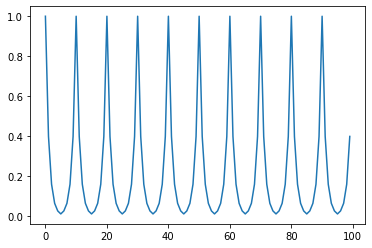

In [480]:
plt.plot(heatrate_values)
plt.show()

In [ ]:
# plt.plot(np.logspace(0, 1, base=200, num=5))
plt.plot(np.logspace(0, 1, base=np.exp(2), num=5))
plt.show()

In [34]:
everyday_grouped_df.loc[~everyday_grouped_df.Time.isna()].iloc[50:100]

,Date_yy-mm-dd,Year,Month,Month_name,Day,Day_name,Day_of_week,Week_of_month,Days_in_month,Activity Type,Distance,Calories,Time,Avg HR,Max HR,Total_nb_activities_per_day,grid_coords_xy
116,2021-04-13,2021,4,April,13,Tuesday,1,2,30,Breathwork,0.00,0.0,15.566667,59.0,88.000000,2,"(2.0, 54.4)"
117,2021-04-13,2021,4,April,13,Tuesday,1,2,30,Cycling,24.54,743.0,91.666667,125.0,161.000000,2,"(2.0, 54.4)"
119,2021-04-15,2021,4,April,15,Thursday,3,2,30,Breathwork,0.00,0.0,15.566667,56.0,86.000000,1,"(6.0, 54.4)"
120,2021-04-16,2021,4,April,16,Friday,4,2,30,Breathwork,0.00,0.0,15.566667,56.0,87.000000,1,"(8.0, 54.4)"
121,2021-04-17,2021,4,April,17,Saturday,5,2,30,Cycling,4.05,128.0,20.616667,108.0,129.000000,1,"(10.0, 54.4)"
122,2021-04-18,2021,4,April,18,Sunday,6,2,30,Breathwork,0.00,0.0,15.566667,55.0,106.000000,2,"(12.0, 54.4)"
123,2021-04-18,2021,4,April,18,Sunday,6,2,30,Cycling,24.30,683.0,92.600000,120.0,148.500000,2,"(12.0, 54.4)"
124,2021-04-19,2021,4,April,19,Monday,0,3,30,Breathwork,0.00,0.0,15.566667,55.0,105.000000,1,"(0.0, 56.4)"
125,2021-04-20,2021,4,April,20,Tuesday,1,3,30,Breathwork,0.00,0.0,26.616667,57.0,69.500000,1,"(2.0, 56.4)"
127,2021-04-22,2021,4,April,22,Thursday,3,3,30,Breathwork,0.00,0.0,11.931667,77.5,96.500000,1,"(6.0, 56.4)"


In [36]:
everyday_grouped_df["Activity Type"].unique()

array([nan, 'Strength Training', 'Breathwork', 'Pilates', 'Yoga',
       'Cardio', 'Cycling', 'Running', 'Tennis', 'Pool Swimming',
       'Football'], dtype=object)